# Multiple Samples Error Rate Analysis

This notebook analyzes error rates across multiple samples by reading their complete_error_dict.pkl files.

## Features:
1. Automatically load all complete_error_dict.pkl files from subfolders
2. Calculate mean error rates and variances for each sample
3. Generate boxplots for error rate comparison
4. Save all results to CSV files and plots

In [3]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os
from glob import glob
import seaborn as sns

# Set style for better looking plots
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

# Load reference library
def read_library(file_path):  
    df = pd.read_excel(file_path)
    index_list = df.iloc[:, 0]
    library = df.iloc[:, 1]
    return index_list, library

# Read reference library
index_list, library = read_library('/home/liuycomputing/lby_FASTQ_data_202408/refLib-SEQ2210.xlsx')
lib_len = len(library[0])

# Define paths
results_folder = '/home/liuycomputing/lby_FASTQ_data_202408/codes/new_process_20260414/results/'
output_folder = '/home/liuycomputing/lby_FASTQ_data_202408/codes/new_process_20260414/analysis_output/'

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

In [4]:
# Function to load pickle file
def load_error_dict_pickle(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

# Find all complete_error_dict.pkl files in subdirectories
pkl_files = sorted(glob(os.path.join(results_folder, '*/whole_error_dict_1.pkl')))
print(f"Found {len(pkl_files)} whole_error_dict_1.pkl files:")
for pkl_file in pkl_files:
    sample_name = os.path.basename(os.path.dirname(pkl_file))
    print(f"  - {sample_name}")

Found 12 whole_error_dict_1.pkl files:
  - TN3055-2
  - TN3055-9
  - TN3132-1
  - TN3132-2
  - TN3132-3
  - TN3132-4
  - TN3196-1
  - TN3196-2
  - TN3196-3
  - TN3196-4
  - TN3196-5
  - TN3196-6


In [5]:
# Load all error dictionaries and store them by sample name
error_dicts = {}
for pkl_file in pkl_files:
    sample_name = os.path.basename(os.path.dirname(pkl_file))
    try:
        error_dict = load_error_dict_pickle(pkl_file)
        error_dicts[sample_name] = error_dict
        print(f"Loaded {sample_name} successfully")
    except Exception as e:
        print(f"Error loading {sample_name}: {e}")

print(f"\nTotal samples loaded: {len(error_dicts)}")

Loaded TN3055-2 successfully
Loaded TN3055-9 successfully
Loaded TN3132-1 successfully
Loaded TN3132-2 successfully
Loaded TN3132-3 successfully
Loaded TN3132-4 successfully
Loaded TN3196-1 successfully
Loaded TN3196-2 successfully
Loaded TN3196-3 successfully
Loaded TN3196-4 successfully
Loaded TN3196-5 successfully
Loaded TN3196-6 successfully

Total samples loaded: 12


In [6]:
print(error_dict.keys())

dict_keys(['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27', 's28', 's29', 's30', 's31', 's32', 's33', 's34', 's35', 's36', 's37', 's38', 's39', 's40', 's41', 's42', 's43', 's44', 's45', 's46', 's47', 's48', 's49', 's50', 's51', 's52', 's53', 's54', 's55', 's56', 's57', 's58', 's59', 's60', 's61', 's62', 's63', 's64', 's65', 's66', 's67', 's68', 's69', 's70', 's71', 's72', 's73', 's74', 's75', 's76', 's77', 's78', 's79', 's80', 's81', 's82', 's83', 's84', 's85', 's86', 's87', 's88', 's89', 's90', 's91', 's92', 's93', 's94', 's95', 's96', 's97', 's98', 's99', 's100', 's101', 's102', 's103', 's104', 's105', 's106', 's107', 's108', 's109', 's110', 's111', 's112', 's113', 's114', 's115', 's116', 's117', 's118', 's119', 's120', 's121', 's122', 's123', 's124', 's125', 's126', 's127', 's128', 's129', 's130', 's131', 's132', 's133', 's134', 's135', 's136', 's137', '

In [7]:
# Function to calculate error rates for a sample
def compute_error_rates_per_sample(error_dict, index_list):
    # Store error rates for each sequence that has valid data
    sequence_rates = []
    
    for idx in index_list:
        if idx not in error_dict:
            continue
            
        data = error_dict[idx]
        right_list = np.array(data['Right'], dtype=float)
        deletion_list = np.array(data['Deletion'], dtype=float)
        insertion_list = np.array(data['Insertion'], dtype=float)
        substitution_list = np.array(data['Substitution'], dtype=float)
        total_num = right_list + deletion_list + insertion_list + substitution_list
        
        # Skip sequences with no data
        if np.mean(total_num) == 0:
            continue
            
        # Calculate error rates
        deletion_rates = deletion_list / total_num
        insertion_rates = insertion_list / total_num
        substitution_rates = substitution_list / total_num
        
        # Calculate mean error rate for this sequence
        mean_deletion = np.mean(deletion_rates)
        mean_insertion = np.mean(insertion_rates)
        mean_substitution = np.mean(substitution_rates)
        mean_total_error = (mean_deletion + mean_insertion + mean_substitution) / 3
        
        sequence_rates.append({
            'deletion': mean_deletion,
            'insertion': mean_insertion,
            'substitution': mean_substitution,
            'total': mean_total_error
        })
    
    return sequence_rates

# Calculate error rates for all samples
sample_error_rates = {}
for sample_name, error_dict in error_dicts.items():
    sequence_rates = compute_error_rates_per_sample(error_dict, index_list)
    if sequence_rates:  # Only add samples that have data
        sample_error_rates[sample_name] = sequence_rates
        print(f"Sample {sample_name}: {len(sequence_rates)} sequences with valid data")

print(f"\nSamples with valid data: {len(sample_error_rates)}")

Sample TN3055-2: 10798 sequences with valid data
Sample TN3055-9: 10796 sequences with valid data
Sample TN3132-1: 10796 sequences with valid data
Sample TN3132-2: 10796 sequences with valid data
Sample TN3132-3: 10798 sequences with valid data
Sample TN3132-4: 10794 sequences with valid data
Sample TN3196-1: 9673 sequences with valid data
Sample TN3196-2: 5160 sequences with valid data
Sample TN3196-3: 4327 sequences with valid data
Sample TN3196-4: 10793 sequences with valid data
Sample TN3196-5: 10796 sequences with valid data
Sample TN3196-6: 10795 sequences with valid data

Samples with valid data: 12


In [8]:
# Calculate mean and variance across samples
summary_data = {}

for error_type in ['deletion', 'insertion', 'substitution', 'total']:
    # Collect all sequence rates for this error type across samples
    all_rates = []
    sample_means = {}
    sample_vars = {}
    
    for sample_name, sequence_rates in sample_error_rates.items():
        rates = [seq[error_type] for seq in sequence_rates]
        all_rates.extend(rates)
        
        # Calculate mean and variance for this sample
        sample_mean = np.mean(rates)
        sample_var = np.var(rates)
        
        sample_means[sample_name] = sample_mean
        sample_vars[sample_name] = sample_var
    
    # Overall statistics
    overall_mean = np.mean(all_rates) if all_rates else 0
    overall_var = np.var(all_rates) if all_rates else 0
    overall_std = np.std(all_rates) if all_rates else 0
    overall_sem = overall_std / np.sqrt(len(all_rates)) if all_rates else 0
    
    summary_data[error_type] = {
        'all_rates': all_rates,
        'sample_means': sample_means,
        'sample_vars': sample_vars,
        'overall_mean': overall_mean,
        'overall_var': overall_var,
        'overall_std': overall_std,
        'overall_sem': overall_sem
    }
    
    print(f"\n{error_type.upper()} Error Rates:")
    print(f"  Overall mean: {overall_mean:.6f}")
    print(f"  Overall variance: {overall_var:.6f}")
    print(f"  Overall std dev: {overall_std:.6f}")
    print(f"  Overall SEM: {overall_sem:.6f}")
    print(f"  Number of samples: {len(sample_means)}")

# Prepare data for box plot
boxplot_data = []
boxplot_labels = []

for error_type in ['deletion', 'insertion', 'substitution', 'total']:
    boxplot_data.append(summary_data[error_type]['all_rates'])
    boxplot_labels.append(error_type.upper())

print(f"\nBox plot data prepared for {len(boxplot_data)} error types")


DELETION Error Rates:
  Overall mean: 0.004684
  Overall variance: 0.000548
  Overall std dev: 0.023403
  Overall SEM: 0.000069
  Number of samples: 12

INSERTION Error Rates:
  Overall mean: 0.000582
  Overall variance: 0.000013
  Overall std dev: 0.003563
  Overall SEM: 0.000010
  Number of samples: 12

SUBSTITUTION Error Rates:
  Overall mean: 0.005743
  Overall variance: 0.000027
  Overall std dev: 0.005165
  Overall SEM: 0.000015
  Number of samples: 12

TOTAL Error Rates:
  Overall mean: 0.003670
  Overall variance: 0.000092
  Overall std dev: 0.009585
  Overall SEM: 0.000028
  Number of samples: 12

Box plot data prepared for 4 error types


/tmp/ipykernel_25613/2928806961.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(boxplot_data,
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 

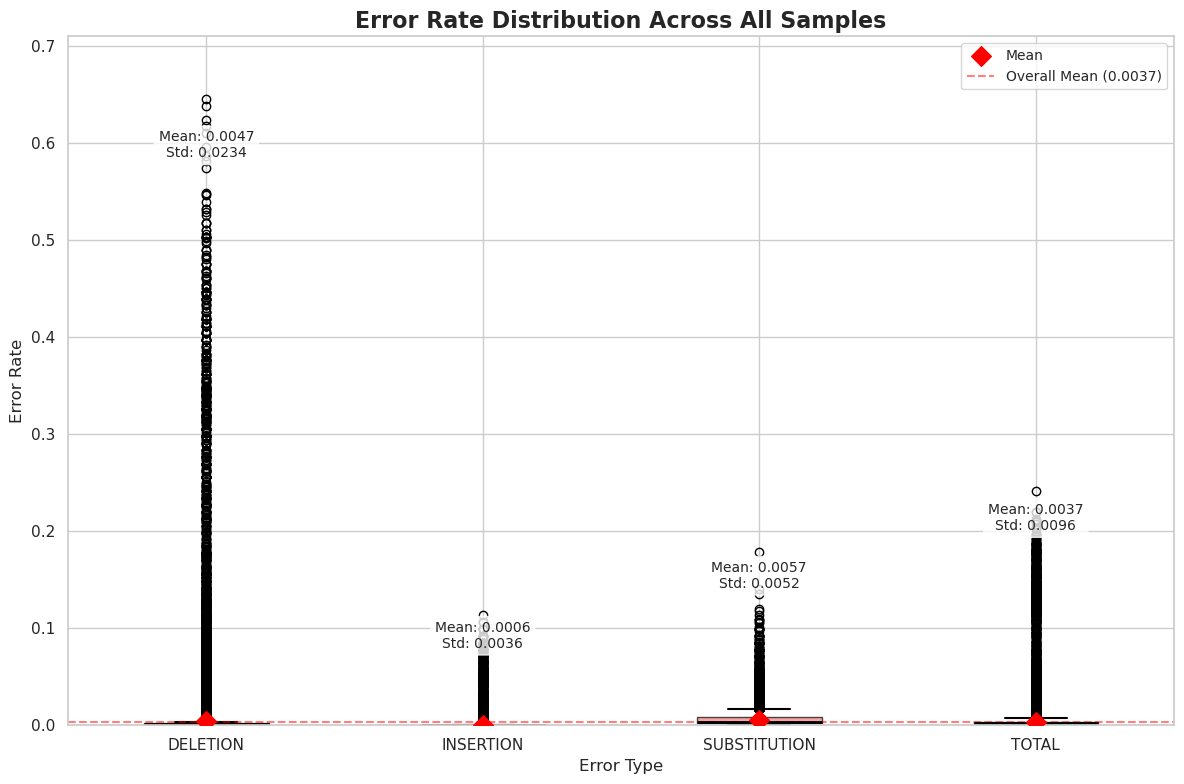

Box plot saved to output folder


In [9]:
# Create box plot comparing error rates across different types
plt.figure(figsize=(12, 8))

# Create box plot
bp = plt.boxplot(boxplot_data, 
                 labels=boxplot_labels,
                 patch_artist=True,
                 medianprops=dict(color='black', linewidth=2),
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5))

# Customize colors for each box
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Add mean values as points
mean_values = [np.mean(data) for data in boxplot_data]
plt.scatter(range(1, len(boxplot_labels)+1), mean_values, 
            color='red', marker='D', s=100, zorder=5, label='Mean')

# Add overall mean line
overall_mean = np.mean([np.mean(data) for data in boxplot_data])
plt.axhline(y=overall_mean, color='red', linestyle='--', alpha=0.5, 
            label=f'Overall Mean ({overall_mean:.4f})')

# Customize plot
plt.title('Error Rate Distribution Across All Samples', fontsize=16, fontweight='bold')
plt.xlabel('Error Type', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max([max(data) for data in boxplot_data]) * 1.1)

# Add statistics annotations
for i, (label, data) in enumerate(zip(boxplot_labels, boxplot_data)):
    if len(data) > 0:
        mean_val = np.mean(data)
        std_val = np.std(data)
        plt.text(i+1, max(data) * 0.95, f'Mean: {mean_val:.4f}\nStd: {std_val:.4f}', 
                ha='center', va='top', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'error_rates_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Box plot saved to output folder")

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

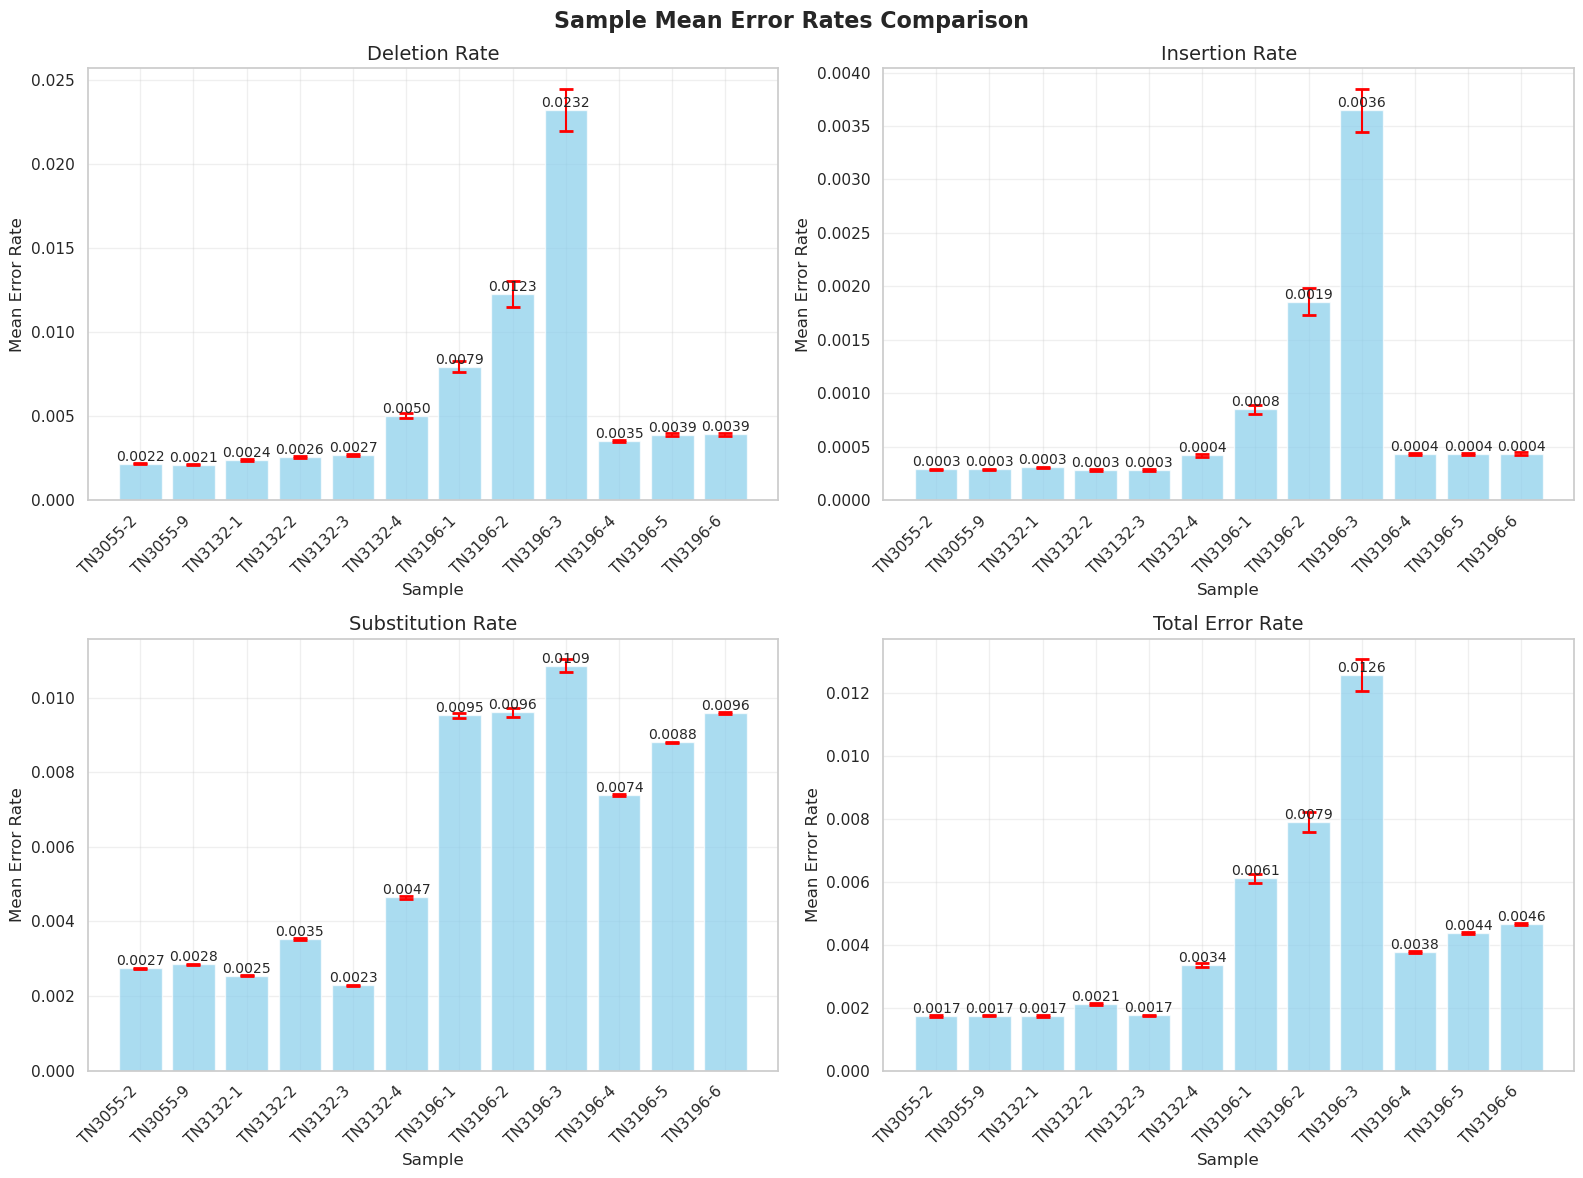

Sample comparison plot saved to output folder


In [10]:
# Create a plot comparing sample means for each error type
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sample Mean Error Rates Comparison', fontsize=16, fontweight='bold')

error_types = ['deletion', 'insertion', 'substitution', 'total']
titles = ['Deletion Rate', 'Insertion Rate', 'Substitution Rate', 'Total Error Rate']

for idx, (error_type, title) in enumerate(zip(error_types, titles)):
    ax = axes[idx//2, idx%2]
    
    # Get sample means
    sample_means = summary_data[error_type]['sample_means']
    sample_names = list(sample_means.keys())
    means = list(sample_means.values())
    
    # Create bar plot
    bars = ax.bar(range(len(sample_names)), means, color='skyblue', alpha=0.7)
    
    # Add error bars for standard deviation
    # Compute SEM (std / sqrt(n)) per sample and plot as error bars
    sample_sems = []
    for name in sample_names:
        n = len(sample_error_rates.get(name, []))
        if n > 0:
            var = summary_data[error_type]['sample_vars'].get(name, 0.0)
            sem = np.sqrt(var / n)
        else:
            sem = 0.0
        sample_sems.append(sem)

    ax.errorbar(range(len(sample_names)), means, yerr=sample_sems, 
                fmt='none', ecolor='red', capsize=5, capthick=2)
    
    # Customize plot
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Sample', fontsize=12)
    ax.set_ylabel('Mean Error Rate', fontsize=12)
    ax.set_xticks(range(len(sample_names)))
    ax.set_xticklabels(sample_names, rotation=45, ha='right')
    
    # Set unified y-axis range
    # ax.set_ylim(-0.021, 0.05)
    
    # Add value labels on bars
    for i, (bar, mean) in enumerate(zip(bars, means)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{mean:.4f}', ha='center', va='bottom', fontsize=10)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'sample_means_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Sample comparison plot saved to output folder")

In [35]:
# Save summary statistics to CSV files
# 1. Save overall statistics
overall_stats = []
for error_type in ['deletion', 'insertion', 'substitution', 'total']:
    data = summary_data[error_type]
    overall_stats.append([
        error_type.upper(),
        len(data['all_rates']),
        data['overall_mean'],
        data['overall_var'],
        data['overall_std']
    ])

overall_df = pd.DataFrame(overall_stats, 
                         columns=['Error_Type', 'Count', 'Mean', 'Variance', 'Std_Dev'])
overall_df.to_csv(os.path.join(output_folder, 'overall_error_statistics.csv'), index=False)

# 2. Save sample statistics
sample_stats_rows = []
for error_type in ['deletion', 'insertion', 'substitution', 'total']:
    for sample_name, mean in summary_data[error_type]['sample_means'].items():
        sample_stats_rows.append([
            sample_name,
            error_type.upper(),
            mean,
            summary_data[error_type]['sample_vars'][sample_name]
        ])

sample_df = pd.DataFrame(sample_stats_rows, 
                        columns=['Sample', 'Error_Type', 'Mean', 'Variance'])
sample_df.to_csv(os.path.join(output_folder, 'sample_error_statistics.csv'), index=False)

# 3. Save raw error rate data for each error type
for error_type in ['deletion', 'insertion', 'substitution', 'total']:
    # Create DataFrame with all sequence rates
    all_data = []
    for sample_name, sequence_rates in sample_error_rates.items():
        for seq_idx, seq_data in enumerate(sequence_rates):
            all_data.append([
                sample_name,
                f"Sequence_{seq_idx+1}",
                seq_data[error_type]
            ])
    
    error_df = pd.DataFrame(all_data, columns=['Sample', 'Sequence', error_type.upper()])
    error_df.to_csv(os.path.join(output_folder, f'{error_type}_error_rates.csv'), index=False)

print("All statistics saved to CSV files")
print(f"\nFiles saved in {output_folder}:")
print("- overall_error_statistics.csv")
print("- sample_error_statistics.csv")
print("- deletion_error_rates.csv")
print("- insertion_error_rates.csv")
print("- substitution_error_rates.csv")
print("- total_error_rates.csv")
print("- error_rates_boxplot.png")
print("- sample_means_comparison.png")

All statistics saved to CSV files

Files saved in /home/liuycomputing/lby_FASTQ_data_202408/new_process_20260414/analysis_output/:
- overall_error_statistics.csv
- sample_error_statistics.csv
- deletion_error_rates.csv
- insertion_error_rates.csv
- substitution_error_rates.csv
- total_error_rates.csv
- error_rates_boxplot.png
- sample_means_comparison.png


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.



=== CORRELATION ANALYSIS ===
Correlation Matrix between Error Types:
               Deletion    Insertion   Substitution
Deletion       1.0000     0.8054      0.3681
Insertion      0.8054     1.0000      0.4485
Substitution   0.3681     0.4485      1.0000


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

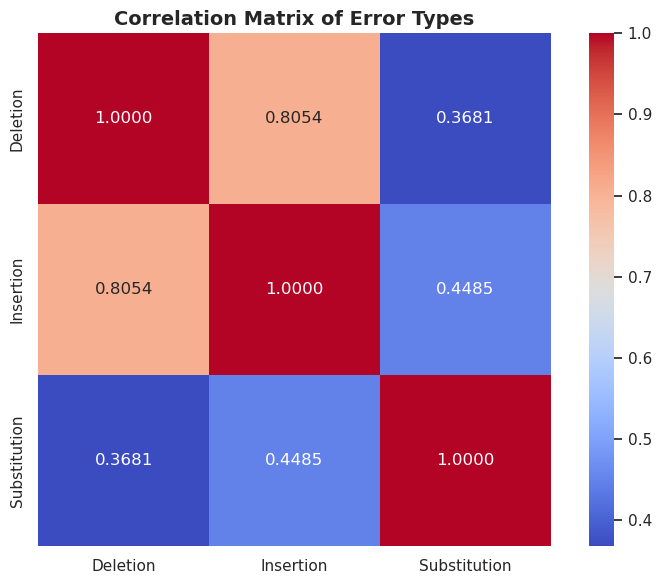

Correlation heatmap saved to output folder

Analysis complete! Check the output folder for all results.


In [36]:
# Additional analysis: Calculate correlation between error types
print("\n=== CORRELATION ANALYSIS ===")

# Extract all error rates for correlation analysis
deletion_rates = []
insertion_rates = []
substitution_rates = []

for sample_name, sequence_rates in sample_error_rates.items():
    for seq_data in sequence_rates:
        deletion_rates.append(seq_data['deletion'])
        insertion_rates.append(seq_data['insertion'])
        substitution_rates.append(seq_data['substitution'])

# Calculate correlation matrix
correlation_matrix = np.corrcoef([deletion_rates, insertion_rates, substitution_rates])

print("Correlation Matrix between Error Types:")
print("               Deletion    Insertion   Substitution")
print(f"Deletion       {correlation_matrix[0,0]:.4f}     {correlation_matrix[0,1]:.4f}      {correlation_matrix[0,2]:.4f}")
print(f"Insertion      {correlation_matrix[1,0]:.4f}     {correlation_matrix[1,1]:.4f}      {correlation_matrix[1,2]:.4f}")
print(f"Substitution   {correlation_matrix[2,0]:.4f}     {correlation_matrix[2,1]:.4f}      {correlation_matrix[2,2]:.4f}")

# Create correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            xticklabels=['Deletion', 'Insertion', 'Substitution'],
            yticklabels=['Deletion', 'Insertion', 'Substitution'],
            square=True,
            fmt='.4f')
plt.title('Correlation Matrix of Error Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved to output folder")
print("\nAnalysis complete! Check the output folder for all results.")

In [37]:
# Print final summary
print("\n=== FINAL ANALYSIS SUMMARY ===")
print(f"Total samples processed: {len(sample_error_rates)}")
print(f"Total sequences analyzed: {sum(len(rates) for rates in sample_error_rates.values())}")

for error_type in ['deletion', 'insertion', 'substitution', 'total']:
    data = summary_data[error_type]
    print(f"\n{error_type.upper()} Error Rates:")
    print(f"  Mean: {data['overall_mean']:.6f}")
    print(f"  Variance: {data['overall_var']:.6f}")
    print(f"  Standard Deviation: {data['overall_std']:.6f}")
    print(f"  Sequences analyzed: {len(data['all_rates'])}")

print(f"\nAll output files are saved in: {output_folder}")


=== FINAL ANALYSIS SUMMARY ===
Total samples processed: 12
Total sequences analyzed: 116322

DELETION Error Rates:
  Mean: 0.004684
  Variance: 0.000548
  Standard Deviation: 0.023403
  Sequences analyzed: 116322

INSERTION Error Rates:
  Mean: 0.000582
  Variance: 0.000013
  Standard Deviation: 0.003563
  Sequences analyzed: 116322

SUBSTITUTION Error Rates:
  Mean: 0.005743
  Variance: 0.000027
  Standard Deviation: 0.005165
  Sequences analyzed: 116322

TOTAL Error Rates:
  Mean: 0.003670
  Variance: 0.000092
  Standard Deviation: 0.009585
  Sequences analyzed: 116322

All output files are saved in: /home/liuycomputing/lby_FASTQ_data_202408/new_process_20260414/analysis_output/
